# Google 員工多元化聚類分析

**任務**：運用無監督學習探索產業／領域間的人口統計模式，找出多元化構成相似的集群，並標記可能需要政策關注的異常群體。

**資料來源**：`dataset-google.csv`（Google 年度多元化報告公開摘要，含 sector → subsector → industry_group → industry 階層與 2020–2023 年面板資料）

---

## 分析問題
1. 哪些行業在性別與種族方面有相似的人口結構？
2. 哪三個行業的性別比例最不平衡？與勞動力總規模有何關係？
3. 2021–2023 年間，哪三個產業的勞動力多元變化最為顯著？
4. 哪些行業由單一族群主導？不平衡程度有多嚴重？
5. 哪些產業的種族多樣性最高？與產業規模有何關係？
6. 能否根據相似的種族組成對產業進行分組？

## 0. 環境設定

In [1]:
from IPython.display import display
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

DATA_PATH = Path("dataset-google.csv")
RANDOM_STATE = 42
DEMO_COLS = [
    "percent_women",
    "percent_white",
    "percent_black_or_african_american",
    "percent_asian",
    "percent_hispanic_or_latino",
]
RACE_COLS = DEMO_COLS[1:]

/Users/Dennis/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. 資料載入與預處理

### 設計決策

| 決策 | 理由 |
|------|------|
| **分析單位**：取每列最細粒度標籤（industry → industry_group → subsector → sector） | 資料同時含總體 sector 列與細分 industry 列；統一標籤才能可比較 |
| **比例標準化**：若任一比例 > 1，整列除以 100 | 少數列（如 Construction sector）以 0–100 儲存，其餘為 0–1 |
| **排除「Total, 16 years and over」** | 為經濟總量基準列，非可比產業 |
| **橫截面基準年：2023** | 聚類與失衡排名用最新快照；變化分析用 2021→2023 面板 |
| **最小就業門檻** | 細分行業樣本極小時比例不穩定；主要排名設 `≥100` 千人，變化分析設 `≥50` 千人 |

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"原始列數：{len(raw):,}")
raw.head()

原始列數：1,272


,year,sector,subsector,industry_group,industry,total_employed_in_thousands,percent_women,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino
0,2022.0,Education and health services,NaN,NaN,NaN,35377.0,0.746,0.745,0.154,0.068,0.137
1,2021.0,Education and health services,NaN,NaN,NaN,34725.0,0.743,0.752,0.148,0.067,0.133
2,2023.0,Manufacturing,NaN,NaN,NaN,15570.0,0.295,0.784,0.108,0.076,0.181
3,2021.0,Transportation and utilities,NaN,NaN,NaN,9377.0,0.248,0.712,0.196,0.055,0.201
4,2021.0,"Total, 16 years and over",NaN,NaN,NaN,152581.0,0.470,0.780,0.120,0.660,0.180


In [3]:
def normalize_percent_columns(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """將混用 0–1 與 0–100 的比例欄位統一為 0–1。"""
    out = df.copy()
    demo = out[cols].apply(pd.to_numeric, errors="coerce")
    needs_scale = demo.gt(1).any(axis=1)
    scaled = demo.copy()
    scaled.loc[needs_scale] = demo.loc[needs_scale] / 100.0
    out[cols] = scaled
    return out


def finest_label(row: pd.Series) -> str:
    for col in ["industry", "industry_group", "subsector", "sector"]:
        val = row.get(col)
        if pd.notna(val) and str(val).strip():
            return str(val).strip()
    return "Unknown"


def hierarchy_path(row: pd.Series) -> str:
    parts = []
    for col in ["sector", "subsector", "industry_group", "industry"]:
        val = row.get(col)
        parts.append(str(val).strip() if pd.notna(val) and str(val).strip() else "")
    return " > ".join(parts)


df = normalize_percent_columns(raw, DEMO_COLS)
df["entity_label"] = df.apply(finest_label, axis=1)
df["entity_path"] = df.apply(hierarchy_path, axis=1)
df["total_employed_in_thousands"] = pd.to_numeric(
    df["total_employed_in_thousands"], errors="coerce"
)

df = df[~df["entity_label"].str.contains("Total, 16 years", na=False)].copy()
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

print("年份範圍：", sorted(df["year"].dropna().unique()))
print("唯一 entity_path 數：", df["entity_path"].nunique())
df[["year", "entity_label", "entity_path"] + DEMO_COLS + ["total_employed_in_thousands"]].head(8)

年份範圍： [2020, 2021, 2022, 2023]
唯一 entity_path 數： 318


,year,entity_label,entity_path,percent_women,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino,total_employed_in_thousands
0,2022,Education and health services,Education and health services > > >,0.746,0.745,0.154,0.068,0.137,35377.0
1,2021,Education and health services,Education and health services > > >,0.743,0.752,0.148,0.067,0.133,34725.0
2,2023,Manufacturing,Manufacturing > > >,0.295,0.784,0.108,0.076,0.181,15570.0
3,2021,Transportation and utilities,Transportation and utilities > > >,0.248,0.712,0.196,0.055,0.201,9377.0
5,2021,"Mining, quarrying, and oil and gas extraction","Mining, quarrying, and oil and gas extraction ...",0.154,0.869,0.059,0.036,0.171,603.0
6,2023,Transportation and utilities,Transportation and utilities > > >,0.243,0.701,0.207,0.056,0.211,9949.0
7,2023,"Mining, quarrying, and oil and gas extraction","Mining, quarrying, and oil and gas extraction ...",0.153,0.877,0.063,0.028,0.225,590.0
8,2022,Construction,Construction > > >,0.109,0.873,0.067,0.021,0.342,11790.0


In [4]:
# 驗證比例已落在合理區間
summary = df[DEMO_COLS].describe().T[["min", "max", "mean"]]
summary

,min,max,mean
percent_women,0.030,0.960,0.410671
percent_white,0.040,0.980,0.786626
percent_black_or_african_american,0.000,0.374,0.114761
percent_asian,0.000,0.440,0.062725
percent_hispanic_or_latino,0.023,0.465,0.172909


## 2. 探索性資料分析（EDA）

/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/2872564488.py:32: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/2872564488.py:32: UserWarning: Glyph 22899 (\N{CJK UNIFIED IDEOGRAPH-5973}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/2872564488.py:32: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/2872564488.py:32: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/2872564488.py:32: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipyker

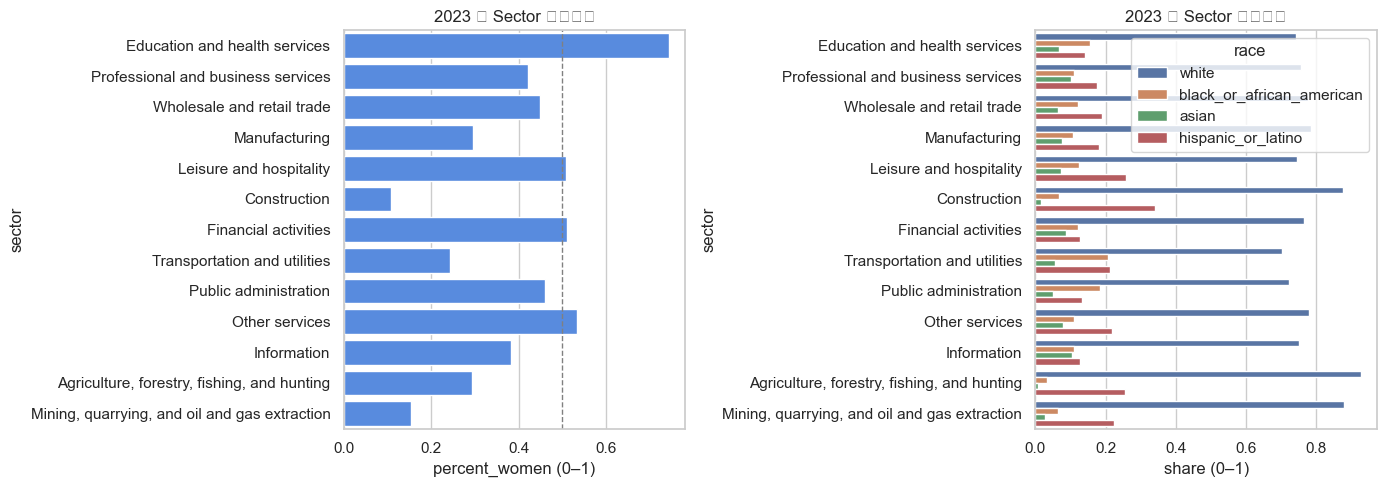

In [5]:
latest = df[df["year"] == df["year"].max()].copy()
sector_latest = latest[
    latest["sector"].notna()
    & latest["subsector"].isna()
    & latest["industry_group"].isna()
    & latest["industry"].isna()
].sort_values("total_employed_in_thousands", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=sector_latest,
    y="sector",
    x="percent_women",
    ax=axes[0],
    color="#4285F4",
)
axes[0].axvline(0.5, color="gray", ls="--", lw=1)
axes[0].set_title("2023 各 Sector 女性比例")
axes[0].set_xlabel("percent_women (0–1)")

race_melt = sector_latest.melt(
    id_vars="sector",
    value_vars=RACE_COLS,
    var_name="race",
    value_name="share",
)
race_melt["race"] = race_melt["race"].str.replace("percent_", "")
sns.barplot(data=race_melt, y="sector", x="share", hue="race", ax=axes[1])
axes[1].set_title("2023 各 Sector 種族組成")
axes[1].set_xlabel("share (0–1)")
plt.tight_layout()
plt.show()

/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1020009548.py:4: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1020009548.py:4: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1020009548.py:4: UserWarning: Glyph 32113 (\N{CJK UNIFIED IDEOGRAPH-7D71}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1020009548.py:4: UserWarning: Glyph 35336 (\N{CJK UNIFIED IDEOGRAPH-8A08}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1020009548.py:4: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_1

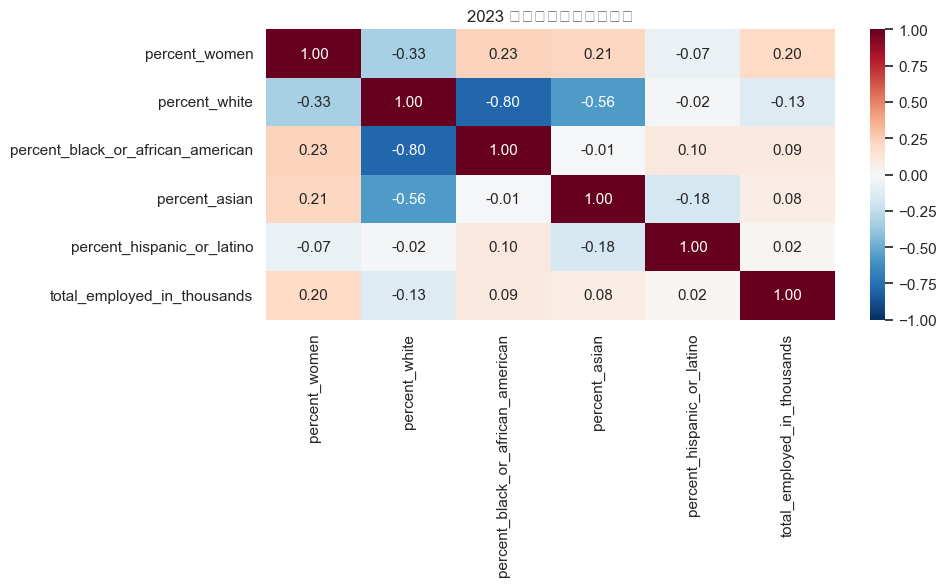

In [6]:
corr = latest[DEMO_COLS + ["total_employed_in_thousands"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("2023 人口統計特徵相關矩陣")
plt.tight_layout()
plt.show()

## 3. 特徵工程

聚類使用五維人口向量：**女性比例 + 四個種族比例**。種族比例在部分列加總略小於 1（未涵蓋其他類別），聚類前將四族比例**重新正規化為加總 1**，使種族空間可比。

另計算兩個解釋性指標（不用於聚類，用於業務問答）：
- **性別失衡**：`|percent_women − 0.5|`
- **種族多樣性**：`1 − HHI`（HHI = Σ pᵢ²，越高代表越由單一族群主導）

In [7]:
def add_derived_metrics(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    race = out[RACE_COLS].astype(float)
    race_sum = race.sum(axis=1).replace(0, np.nan)
    race_norm = race.div(race_sum, axis=0)
    out["gender_imbalance"] = (out["percent_women"] - 0.5).abs()
    out["race_hhi"] = (race_norm**2).sum(axis=1)
    out["race_diversity"] = 1 - out["race_hhi"]
    for col in RACE_COLS:
        out[f"{col}_norm"] = race_norm[col]
    return out


df = add_derived_metrics(df)
latest = df[df["year"] == df["year"].max()].copy()

# 每個 entity_path 只保留一列（最細粒度路徑唯一）
snapshot = latest.drop_duplicates(subset="entity_path").copy()
print(f"2023 分析快照：{len(snapshot)} 個實體")
snapshot[["entity_label", "gender_imbalance", "race_diversity", "total_employed_in_thousands"]].describe()

2023 分析快照：317 個實體


,gender_imbalance,race_diversity,total_employed_in_thousands
count,282.000000,317.000000,317.000000
mean,0.186922,0.535629,1616.943218
std,0.113276,0.185100,3856.093246
min,0.002000,0.170576,0.000000
25%,0.088250,0.430190,95.000000
50%,0.192000,0.495745,331.000000
75%,0.273000,0.567847,1186.000000
max,0.446000,1.000000,36378.000000


## 4. 無監督聚類

### 方法選擇
- **StandardScaler**：KMeans 對量綱敏感；五維比例雖同為 0–1，但變異幅度不同，標準化可避免某一維主導。
- **KMeans**：可解釋、可擴展；適合發現球形集群。
- **Agglomerative Clustering（Ward）**：層次聚類，用樹狀圖展示產業間相似度層級。
- **PCA**：將 5 維人口空間投影至 2D 供視覺化（**僅用於解釋**，不替代聚類）。

K 的選擇：在 K=2..8 計算 **inertia（肘部法）** 與 **silhouette score**，取 silhouette 最高且具業務可解釋性的 K。

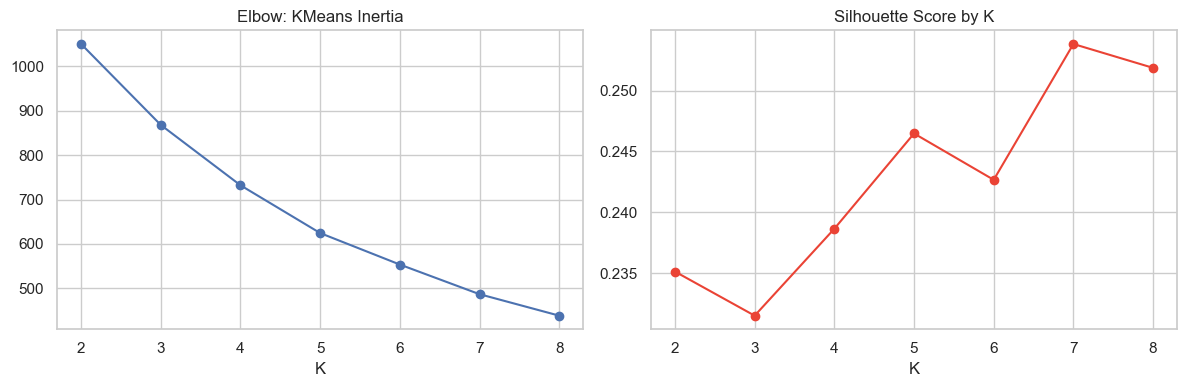

Silhouette 最佳 K = 7（score=0.254）


In [8]:
MIN_EMP_CLUSTER = 50  # 千人；排除極小樣本避免噪聲主導聚類

cluster_base = snapshot[snapshot["total_employed_in_thousands"] >= MIN_EMP_CLUSTER].copy()
feature_cols = ["percent_women"] + [f"{c}_norm" for c in RACE_COLS]
X = cluster_base[feature_cols].astype(float).values
X_scaled = StandardScaler().fit_transform(X)

ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_title("Elbow: KMeans Inertia")
axes[0].set_xlabel("K")
axes[1].plot(list(ks), silhouettes, marker="o", color="#EA4335")
axes[1].set_title("Silhouette Score by K")
axes[1].set_xlabel("K")
plt.tight_layout()
plt.show()

best_k = list(ks)[int(np.argmax(silhouettes))]
print(f"Silhouette 最佳 K = {best_k}（score={max(silhouettes):.3f}）")

PCA 解釋變異比： [0.397 0.268]


/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1801955357.py:29: UserWarning: Glyph 25237 (\N{CJK UNIFIED IDEOGRAPH-6295}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1801955357.py:29: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1801955357.py:29: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1801955357.py:29: UserWarning: Glyph 32676 (\N{CJK UNIFIED IDEOGRAPH-7FA4}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1801955357.py:29: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipyker

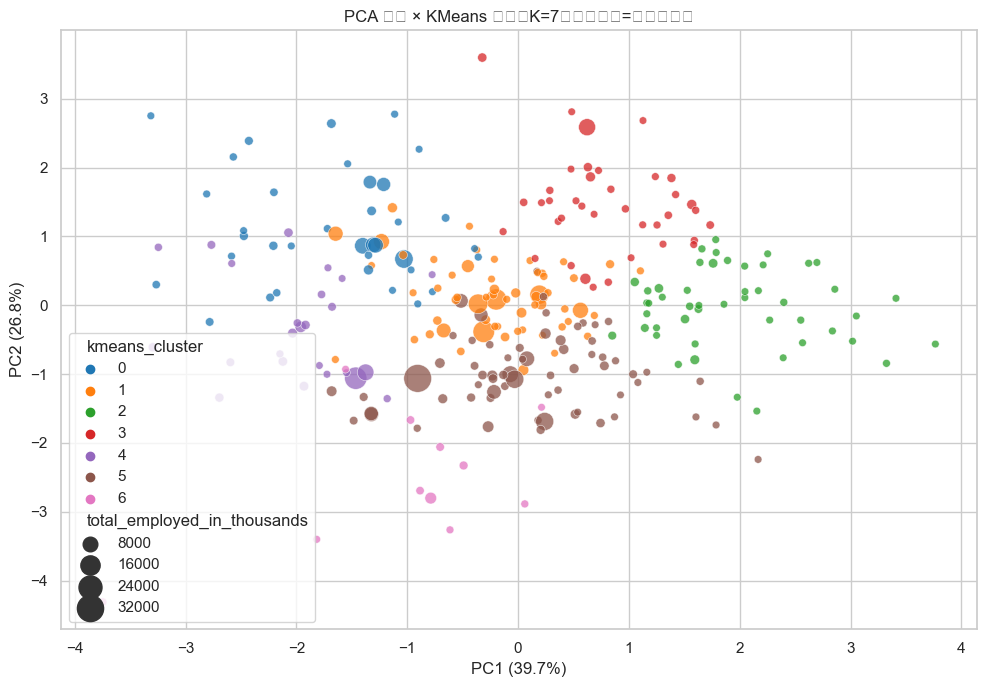

In [9]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
cluster_base["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
cluster_base["agg_cluster"] = agg.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
cluster_base["pca1"] = coords[:, 0]
cluster_base["pca2"] = coords[:, 1]

print("PCA 解釋變異比：", pca.explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=cluster_base,
    x="pca1",
    y="pca2",
    hue="kmeans_cluster",
    size="total_employed_in_thousands",
    sizes=(30, 400),
    alpha=0.75,
    palette="tab10",
    ax=ax,
)
ax.set_title(f"PCA 投影 × KMeans 集群（K={best_k}，氣泡大小=就業規模）")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.show()

In [10]:
cluster_profile = (
    cluster_base.groupby("kmeans_cluster")[DEMO_COLS + ["gender_imbalance", "race_diversity", "total_employed_in_thousands"]]
    .agg(["mean", "count"])
    .round(3)
)
cluster_profile

percent_women       percent_white        \
                        mean count          mean count   
kmeans_cluster                                           
0                      0.494    36         0.727    36   
1                      0.322    59         0.752    59   
2                      0.244    48         0.874    48   
3                      0.230    38         0.855    38   
4                      0.600    25         0.664    25   
5                      0.598    65         0.787    65   
6                      0.395    11         0.658    11   

               percent_black_or_african_american       percent_asian        \
                                            mean count          mean count   
kmeans_cluster                                                               
0                                          0.160    36         0.070    36   
1                                          0.148    59         0.062    59   
2                                          0.058    48         0.039    48   
3                                          0.073    38         0.030    38   
4                                          0.242    25         0.052    25   
5                                          0.104    65         0.075    65   
6                                          0.078    11         0.236    11   

               percent_hispanic_or_latino       gender_imbalance        \
                                     mean count             mean count   
kmeans_cluster                                                           
0                                   0.304    36            0.117    36   
1                                   0.164    59            0.178    59   
2                                   0.132    48            0.257    48   
3                                   0.255    38            0.270    38   
4                                   0.154    25            0.221    25   
5                                   0.135    65            0.125    65   
6                                   0.118    11            0.155    11   

               race_diversity       total_employed_in_thousands        
                         mean count                        mean count  
kmeans_cluster                                                         
0                       0.583    36                    2055.417    36  
1                       0.508    59                    2587.254    59  
2                       0.349    48                     345.938    48  
3                       0.451    38                     831.395    38  
4                       0.568    25                    2160.440    25  
5                       0.454    65                    2672.108    65  
6                       0.562    11                     812.182    11

/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/948455053.py:15: UserWarning: Glyph 35215 (\N{CJK UNIFIED IDEOGRAPH-898F}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/948455053.py:15: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/948455053.py:15: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/948455053.py:15: UserWarning: Glyph 29986 (\N{CJK UNIFIED IDEOGRAPH-7522}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/948455053.py:15: UserWarning: Glyph 26989 (\N{CJK UNIFIED IDEOGRAPH-696D}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_1

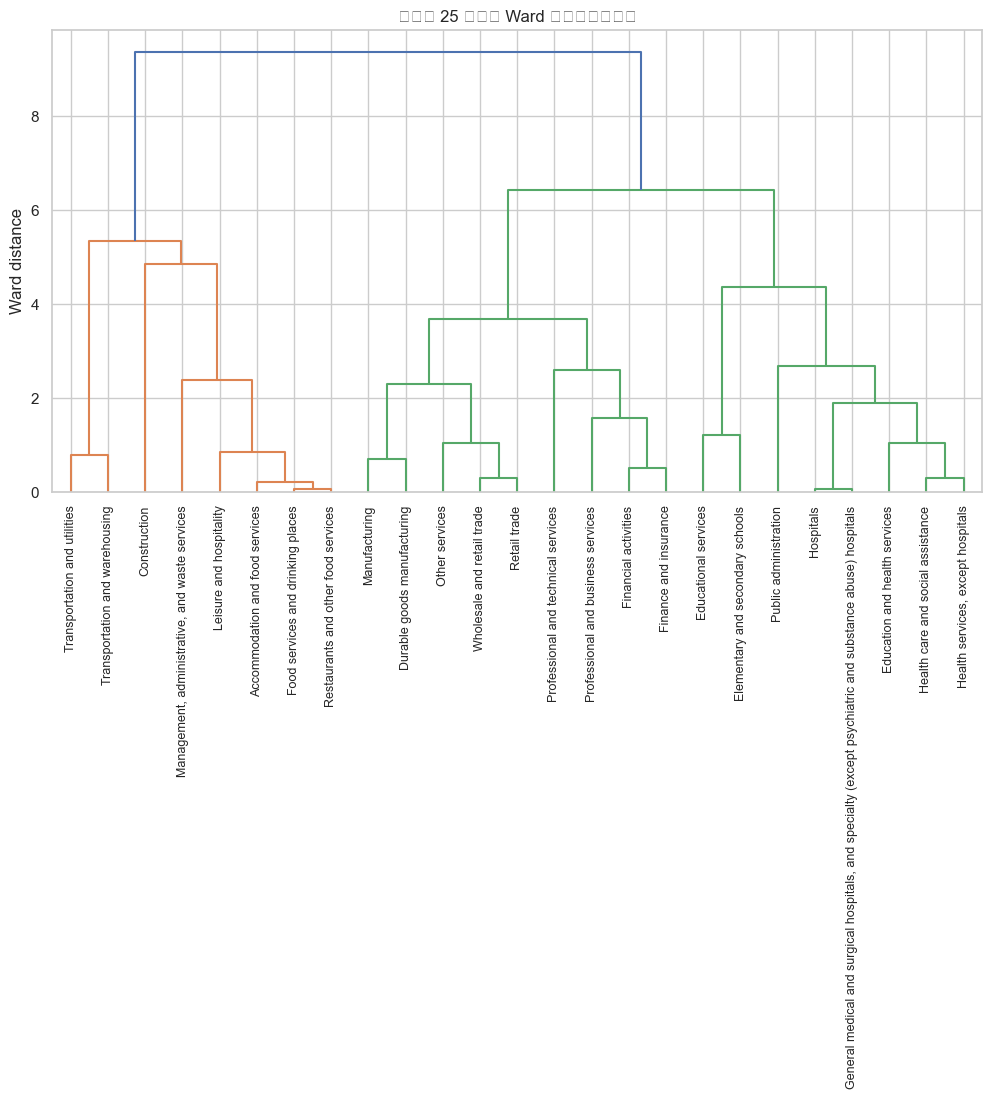

In [11]:
# 層次聚類樹狀圖（取規模前 25 名產業以保持可讀性）
top_n = cluster_base.nlargest(25, "total_employed_in_thousands")
X_top = StandardScaler().fit_transform(top_n[feature_cols].astype(float).values)
link = linkage(X_top, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(
    link,
    labels=top_n["entity_label"].tolist(),
    leaf_rotation=90,
    leaf_font_size=9,
)
plt.title("規模前 25 產業的 Ward 層次聚類樹狀圖")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()

## 5. 業務問題回答

以下函式將分析邏輯封裝為可重複執行的程式，輸出表格供解讀。

In [12]:
MIN_EMP_RANK = 100
rank_base = snapshot[snapshot["total_employed_in_thousands"] >= MIN_EMP_RANK].copy()


def show_table(title: str, frame: pd.DataFrame) -> pd.DataFrame:
    print(f"\n{'='*60}\n{title}\n{'='*60}")
    display(frame)
    return frame

### Q1 & Q6：哪些行業人口結構相似？能否依種族組成分組？

KMeans 同時使用性別 + 種族五維特徵（Q1）；若**僅用四維種族比例**重新聚類，則直接回答 Q6。

In [13]:
# Q1：全人口結構集群成員（每群列出代表產業）
q1_summary = []
for cid, grp in cluster_base.groupby("kmeans_cluster"):
    top_members = grp.nlargest(5, "total_employed_in_thousands")[[
        "entity_label", "percent_women", "percent_white", "percent_black_or_african_american",
        "percent_asian", "percent_hispanic_or_latino", "total_employed_in_thousands",
    ]]
    q1_summary.append({
        "cluster": cid,
        "n_entities": len(grp),
        "avg_women": grp["percent_women"].mean(),
        "avg_white": grp["percent_white"].mean(),
        "avg_black": grp["percent_black_or_african_american"].mean(),
        "avg_asian": grp["percent_asian"].mean(),
        "avg_hispanic": grp["percent_hispanic_or_latino"].mean(),
        "top_entities": ", ".join(top_members["entity_label"].tolist()),
    })

q1_df = pd.DataFrame(q1_summary).round(3)
show_table("Q1：KMeans 集群輪廓（性別 + 種族）", q1_df)


Q1：KMeans 集群輪廓（性別 + 種族）


,cluster,n_entities,avg_women,avg_white,avg_black,avg_asian,avg_hispanic,top_entities
0,0,36,0.494,0.727,0.160,0.070,0.304,"Leisure and hospitality, Accommodation and foo..."
1,1,59,0.322,0.752,0.148,0.062,0.164,"Professional and business services, Wholesale ..."
2,2,48,0.244,0.874,0.058,0.039,0.132,"Architectural, engineering, and related servic..."
3,3,38,0.230,0.855,0.073,0.030,0.255,"Construction, Wholesale trade, Agriculture, fo..."
4,4,25,0.600,0.664,0.242,0.052,0.154,"Health care and social assistance, Health serv..."
5,5,65,0.598,0.787,0.104,0.075,0.135,"Education and health services, Educational ser..."
6,6,11,0.395,0.658,0.078,0.236,0.118,"Computer systems design and related services, ..."


,cluster,n_entities,avg_women,avg_white,avg_black,avg_asian,avg_hispanic,top_entities
0,0,36,0.494,0.727,0.160,0.070,0.304,"Leisure and hospitality, Accommodation and foo..."
1,1,59,0.322,0.752,0.148,0.062,0.164,"Professional and business services, Wholesale ..."
2,2,48,0.244,0.874,0.058,0.039,0.132,"Architectural, engineering, and related servic..."
3,3,38,0.230,0.855,0.073,0.030,0.255,"Construction, Wholesale trade, Agriculture, fo..."
4,4,25,0.600,0.664,0.242,0.052,0.154,"Health care and social assistance, Health serv..."
5,5,65,0.598,0.787,0.104,0.075,0.135,"Education and health services, Educational ser..."
6,6,11,0.395,0.658,0.078,0.236,0.118,"Computer systems design and related services, ..."



Q6：僅種族特徵的 KMeans 分組（emp≥100k）


,n,mean_emp_k,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino
race_cluster,,,,,,
0,51,2968.235,0.683,0.203,0.072,0.172
1,44,2337.523,0.777,0.127,0.053,0.302
2,130,1883.723,0.814,0.095,0.057,0.149
3,9,971.556,0.644,0.076,0.248,0.106


/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1782202620.py:23: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1782202620.py:23: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1782202620.py:23: UserWarning: Glyph 31278 (\N{CJK UNIFIED IDEOGRAPH-7A2E}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1782202620.py:23: UserWarning: Glyph 26063 (\N{CJK UNIFIED IDEOGRAPH-65CF}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1782202620.py:23: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1

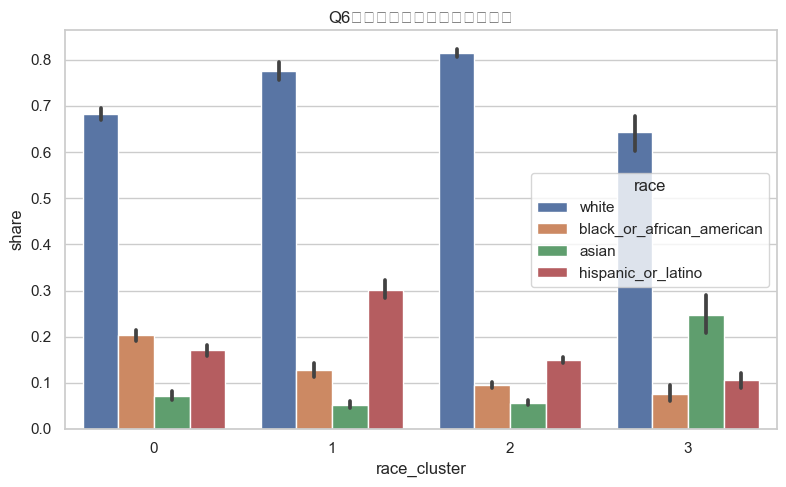

In [14]:
# Q6：僅依種族組成聚類
race_features = [f"{c}_norm" for c in RACE_COLS]
X_race = StandardScaler().fit_transform(rank_base[race_features].astype(float).values)

race_k = 4  # 種族空間較低維，固定 4 群便於解讀（亦可用 silhouette 自動選）
rank_base = rank_base.copy()
rank_base["race_cluster"] = KMeans(n_clusters=race_k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_race)

q6_df = rank_base.groupby("race_cluster").agg(
    n=("entity_label", "count"),
    mean_emp_k=("total_employed_in_thousands", "mean"),
    **{c: (c, "mean") for c in RACE_COLS},
).round(3)
show_table("Q6：僅種族特徵的 KMeans 分組（emp≥100k）", q6_df)

fig, ax = plt.subplots(figsize=(8, 5))
race_melt2 = rank_base.melt(
    id_vars="race_cluster", value_vars=RACE_COLS, var_name="race", value_name="share"
)
race_melt2["race"] = race_melt2["race"].str.replace("percent_", "")
sns.barplot(data=race_melt2, x="race_cluster", y="share", hue="race", ax=ax)
ax.set_title("Q6：各種族集群的平均種族組成")
plt.tight_layout()
plt.show()

### Q2：性別比例最不平衡的三個行業

以 `|percent_women − 0.5|` 衡量偏離性別均勢的程度；並列就業規模以評估政策影響面。


Q2：性別最不平衡的三個行業（emp≥100k）


,entity_label,percent_women,gender_imbalance,total_employed_in_thousands,sector,women_pct,imbalance_pp
500,Child day care services,0.946,0.446,1491.0,Education and health services,94.6,44.6
839,Commercial and industrial machinery and equipm...,0.059,0.441,325.0,Other services,5.9,44.1
258,"Cement, concrete, lime, and gypsum product man...",0.068,0.432,153.0,Manufacturing,6.8,43.2


/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1978594107.py:31: UserWarning: Glyph 23601 (\N{CJK UNIFIED IDEOGRAPH-5C31}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1978594107.py:31: UserWarning: Glyph 26989 (\N{CJK UNIFIED IDEOGRAPH-696D}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1978594107.py:31: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1978594107.py:31: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/1978594107.py:31: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipyker

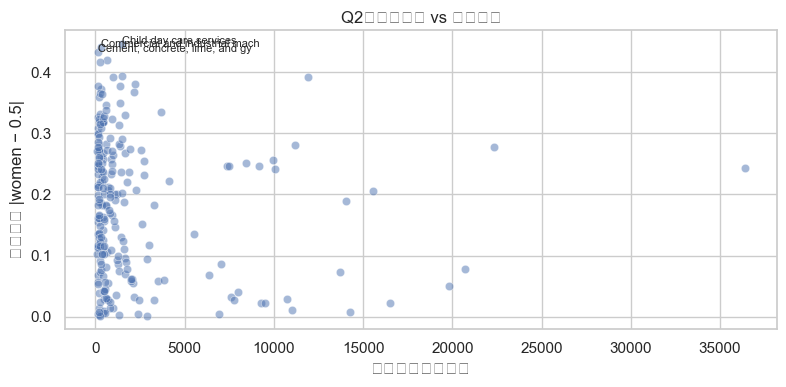

In [15]:
q2 = (
    rank_base.sort_values("gender_imbalance", ascending=False)
    .head(3)[[
        "entity_label", "percent_women", "gender_imbalance",
        "total_employed_in_thousands", "sector",
    ]]
    .assign(
        women_pct=lambda d: (d["percent_women"] * 100).round(1),
        imbalance_pp=lambda d: (d["gender_imbalance"] * 100).round(1),
    )
)
show_table("Q2：性別最不平衡的三個行業（emp≥100k）", q2)

fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(
    data=rank_base,
    x="total_employed_in_thousands",
    y="gender_imbalance",
    alpha=0.5,
    ax=ax,
)
for _, row in q2.iterrows():
    ax.annotate(
        row["entity_label"][:30],
        (row["total_employed_in_thousands"], row["gender_imbalance"]),
        fontsize=8,
    )
ax.set_xlabel("就業人數（千人）")
ax.set_ylabel("性別失衡 |women − 0.5|")
ax.set_title("Q2：性別失衡 vs 產業規模")
plt.tight_layout()
plt.show()

**解讀提示**：高失衡不一定代表「規模小」——例如日託服務（Child day care）女性占比極高且就業人數達百萬級，政策槓桿大；反之機械維修等男性主導行業規模中等但同樣值得關注。

### Q3：2021–2023 多元變化最顯著的三個產業

對五個人口變數計算 **L1 總變化量**（各指標絕對差之和），衡量整體多元化位移。

In [16]:
years_df = df[df["year"].isin([2021, 2023])].copy()
cols_keep = ["entity_path", "entity_label", "year", "total_employed_in_thousands"] + DEMO_COLS
panel = years_df[cols_keep].drop_duplicates(subset=["entity_path", "year"])

p21 = panel[panel["year"] == 2021].set_index("entity_path")
p23 = panel[panel["year"] == 2023].set_index("entity_path")
common_paths = p21.index.intersection(p23.index)

change_rows = []
for path in common_paths:
    row_21 = p21.loc[path]
    row_23 = p23.loc[path]
    emp = row_23["total_employed_in_thousands"]
    if pd.isna(emp) or emp < 50:
        continue
    delta = sum(abs(row_23[c] - row_21[c]) for c in DEMO_COLS)
    change_rows.append({
        "entity_path": path,
        "entity_label": row_23["entity_label"],
        "total_change_l1": delta,
        "emp_2023_k": emp,
        **{f"delta_{c}": row_23[c] - row_21[c] for c in DEMO_COLS},
    })

change_df = pd.DataFrame(change_rows)
q3 = change_df.sort_values("total_change_l1", ascending=False).head(3)
show_table("Q3：2021–2023 多元變化最顯著的三個產業（emp≥50k）", q3.round(3))



Q3：2021–2023 多元變化最顯著的三個產業（emp≥50k）


,entity_path,entity_label,total_change_l1,emp_2023_k,delta_percent_women,delta_percent_white,delta_percent_black_or_african_american,delta_percent_asian,delta_percent_hispanic_or_latino
144,Manufacturing > Nondurable goods manufacturing...,"Bakeries and tortilla manufacturing, except re...",0.497,208.0,0.086,-0.181,0.173,-0.001,-0.056
50,Manufacturing > Durable goods manufacturing > ...,Commercial and service industry machinery manu...,0.481,75.0,-0.125,0.170,-0.068,-0.058,0.060
266,Wholesale and retail trade > Wholesale trade >...,Furniture and home furnishing merchant wholesa...,0.442,72.0,-0.176,-0.098,0.008,0.084,-0.076


,entity_path,entity_label,total_change_l1,emp_2023_k,delta_percent_women,delta_percent_white,delta_percent_black_or_african_american,delta_percent_asian,delta_percent_hispanic_or_latino
144,Manufacturing > Nondurable goods manufacturing...,"Bakeries and tortilla manufacturing, except re...",0.497,208.0,0.086,-0.181,0.173,-0.001,-0.056
50,Manufacturing > Durable goods manufacturing > ...,Commercial and service industry machinery manu...,0.481,75.0,-0.125,0.170,-0.068,-0.058,0.060
266,Wholesale and retail trade > Wholesale trade >...,Furniture and home furnishing merchant wholesa...,0.442,72.0,-0.176,-0.098,0.008,0.084,-0.076


> **注意**：部分細分行業在兩年間變化極大，可能反映 BLS 分類調整、抽樣誤差或比例欄位異常，解讀時應結合原始列與就業規模交叉驗證。

### Q4：單一族群主導的行業


Q4：單一族群主導程度最高的行業（Top 10，emp≥100k）


,entity_label,dominant_race,dominant_race_share,race_hhi,total_employed_in_thousands,dominant_pct
1020,Lawn and garden equipment and supplies stores,White,0.951,0.809159,271.0,95.1
143,Crop production,White,0.946,0.606197,1222.0,94.6
1044,Other motor vehicle dealers,White,0.934,0.707170,175.0,93.4
19,"Agriculture, forestry, fishing, and hunting",White,0.926,0.619211,2264.0,92.6
353,Sawmills and wood preservation,White,0.919,0.701703,115.0,91.9
99,Animal production and aquaculture,White,0.916,0.632692,705.0,91.6
1227,"Machinery, equipment, and supplies merchant wh...",White,0.915,0.690462,326.0,91.5
189,Agricultural implement manufacturing,White,0.914,0.727244,148.0,91.4
185,Furniture and related product manufacturing,White,0.907,0.618635,376.0,90.7
272,"Machine shops; turned product; screw, nut, and...",White,0.898,0.684766,255.0,89.8


/Users/Dennis/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/3648517344.py:30: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/3648517344.py:30: UserWarning: Glyph 23566 (\N{CJK UNIFIED IDEOGRAPH-5C0E}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/3648517344.py:30: UserWarning: Glyph 26063 (\N{CJK UNIFIED IDEOGRAPH-65CF}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/3648517344.py:30: UserWarning: Glyph 32676 (\N{CJK UNIFIED IDEOGRAPH-7FA4}) missing from cur

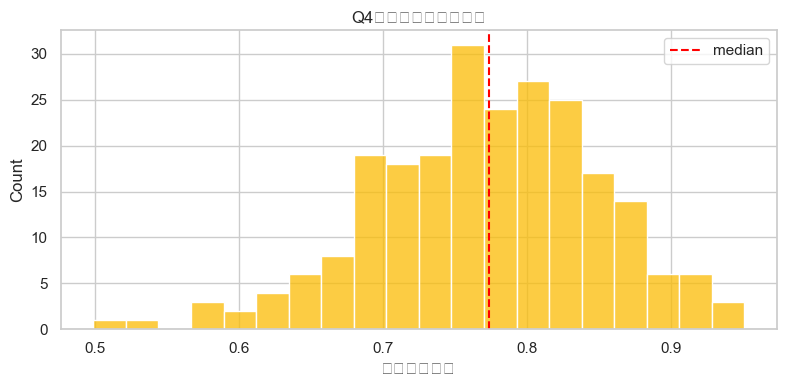

In [17]:
race_labels = {
    "percent_white": "White",
    "percent_black_or_african_american": "Black/African American",
    "percent_asian": "Asian",
    "percent_hispanic_or_latino": "Hispanic/Latino",
}

rank_base["dominant_race_col"] = rank_base[RACE_COLS].idxmax(axis=1)
rank_base["dominant_race_share"] = rank_base.apply(
    lambda r: r[r["dominant_race_col"]], axis=1
)
rank_base["dominant_race"] = rank_base["dominant_race_col"].map(race_labels)

q4 = (
    rank_base.sort_values("dominant_race_share", ascending=False)
    .head(10)[[
        "entity_label", "dominant_race", "dominant_race_share",
        "race_hhi", "total_employed_in_thousands",
    ]]
    .assign(dominant_pct=lambda d: (d["dominant_race_share"] * 100).round(1))
)
show_table("Q4：單一族群主導程度最高的行業（Top 10，emp≥100k）", q4)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(rank_base["dominant_race_share"], bins=20, ax=ax, color="#FBBC04")
ax.axvline(rank_base["dominant_race_share"].median(), color="red", ls="--", label="median")
ax.set_xlabel("主導族群占比")
ax.set_title("Q4：主導族群占比分布")
ax.legend()
plt.tight_layout()
plt.show()

### Q5：種族多樣性最高的產業


Q5：種族多樣性最高（1−HHI）的產業 Top 10


,entity_label,race_diversity,race_hhi,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino,total_employed_in_thousands
1136,Taxi and limousine service,0.693,0.307,0.541,0.253,0.170,0.233,602.0
974,Electronic shopping and mail-order houses,0.657,0.343,0.609,0.200,0.152,0.231,824.0
823,Nail salons and other personal care services,0.651,0.349,0.499,0.063,0.390,0.157,625.0
802,Barber shops,0.650,0.350,0.642,0.299,0.033,0.406,164.0
815,Drycleaning and laundry services,0.644,0.356,0.681,0.146,0.155,0.351,232.0
935,Automotive equipment rental and leasing,0.638,0.362,0.577,0.271,0.077,0.185,180.0
628,Animal slaughtering and processing,0.634,0.366,0.684,0.210,0.068,0.387,434.0
643,"Bakeries and tortilla manufacturing, except re...",0.634,0.366,0.662,0.239,0.056,0.332,208.0
1109,Bus service and urban transit,0.628,0.372,0.580,0.342,0.036,0.192,457.0
457,Home health care services,0.628,0.372,0.623,0.264,0.080,0.195,1387.0


/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/3158215410.py:27: UserWarning: Glyph 23601 (\N{CJK UNIFIED IDEOGRAPH-5C31}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/3158215410.py:27: UserWarning: Glyph 26989 (\N{CJK UNIFIED IDEOGRAPH-696D}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/3158215410.py:27: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/3158215410.py:27: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipykernel_12565/3158215410.py:27: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  plt.tight_layout()
/var/folders/rc/hx9rpq_n1wqgzz42y5z82qjc0000gr/T/ipyker

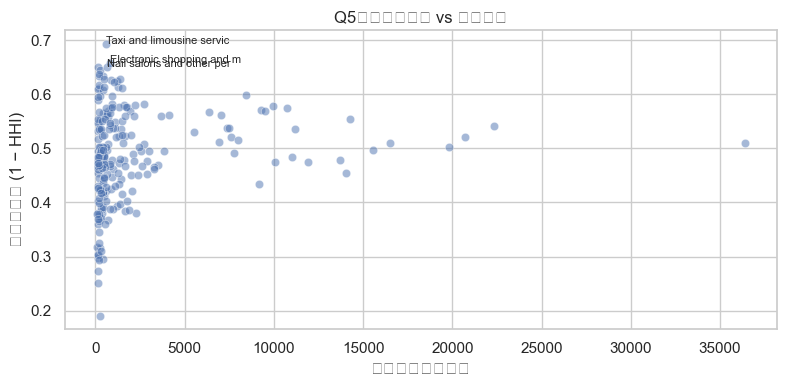

Pearson 相關（多樣性 vs log 規模）：0.261


In [18]:
q5 = (
    rank_base.sort_values("race_diversity", ascending=False)
    .head(10)[[
        "entity_label", "race_diversity", "race_hhi",
        "percent_white", "percent_black_or_african_american",
        "percent_asian", "percent_hispanic_or_latino",
        "total_employed_in_thousands",
    ]]
)
show_table("Q5：種族多樣性最高（1−HHI）的產業 Top 10", q5.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(
    data=rank_base,
    x="total_employed_in_thousands",
    y="race_diversity",
    alpha=0.5,
    ax=ax,
)
for _, row in q5.head(3).iterrows():
    ax.annotate(row["entity_label"][:25], (
        row["total_employed_in_thousands"], row["race_diversity"]
    ), fontsize=8)
ax.set_xlabel("就業人數（千人）")
ax.set_ylabel("種族多樣性 (1 − HHI)")
ax.set_title("Q5：種族多樣性 vs 產業規模")
plt.tight_layout()
plt.show()

print(
    f"Pearson 相關（多樣性 vs log 規模）："
    f"{rank_base['race_diversity'].corr(np.log1p(rank_base['total_employed_in_thousands'])):.3f}"
)

## 6. 異常偵測（政策關注候選）

在 PCA 空間計算各點到集群中心的距離，距離最遠者視為「人口結構異常」產業。

In [19]:
centroids = cluster_base.groupby("kmeans_cluster")[["pca1", "pca2"]].transform("mean")
cluster_base["dist_to_centroid"] = np.sqrt(
    (cluster_base["pca1"] - centroids["pca1"]) ** 2
    + (cluster_base["pca2"] - centroids["pca2"]) ** 2
)

anomalies = cluster_base.nlargest(10, "dist_to_centroid")[[
    "entity_label", "kmeans_cluster", "dist_to_centroid",
    "percent_women", "percent_white", "percent_black_or_african_american",
    "percent_asian", "percent_hispanic_or_latino", "total_employed_in_thousands",
]]
show_table("PCA 空間距離集群中心最遠的 10 個產業（異常候選）", anomalies.round(3))


PCA 空間距離集群中心最遠的 10 個產業（異常候選）


,entity_label,kmeans_cluster,dist_to_centroid,percent_women,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino,total_employed_in_thousands
823,Nail salons and other personal care services,6,3.253,0.772,0.499,0.063,0.390,0.157,625.0
531,Landscaping services,3,2.422,0.107,0.857,0.081,0.015,0.465,1491.0
466,Offices of chiropractors,5,2.380,0.699,0.866,0.043,0.052,0.044,136.0
802,Barber shops,0,2.305,0.339,0.642,0.299,0.033,0.406,164.0
518,Logging,2,1.878,0.091,0.901,0.057,0.000,0.034,72.0
814,Personal and laundry services,5,1.833,0.732,0.697,0.118,0.148,0.194,2746.0
794,"Business, professional, political, and similar...",5,1.810,0.615,0.863,0.061,0.052,0.066,145.0
1136,Taxi and limousine service,0,1.792,0.162,0.541,0.253,0.170,0.233,602.0
974,Electronic shopping and mail-order houses,0,1.763,0.475,0.609,0.200,0.152,0.231,824.0
1048,Pharmacies and drug stores,5,1.752,0.700,0.684,0.138,0.137,0.142,808.0


,entity_label,kmeans_cluster,dist_to_centroid,percent_women,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino,total_employed_in_thousands
823,Nail salons and other personal care services,6,3.253,0.772,0.499,0.063,0.390,0.157,625.0
531,Landscaping services,3,2.422,0.107,0.857,0.081,0.015,0.465,1491.0
466,Offices of chiropractors,5,2.380,0.699,0.866,0.043,0.052,0.044,136.0
802,Barber shops,0,2.305,0.339,0.642,0.299,0.033,0.406,164.0
518,Logging,2,1.878,0.091,0.901,0.057,0.000,0.034,72.0
814,Personal and laundry services,5,1.833,0.732,0.697,0.118,0.148,0.194,2746.0
794,"Business, professional, political, and similar...",5,1.810,0.615,0.863,0.061,0.052,0.066,145.0
1136,Taxi and limousine service,0,1.792,0.162,0.541,0.253,0.170,0.233,602.0
974,Electronic shopping and mail-order houses,0,1.763,0.475,0.609,0.200,0.152,0.231,824.0
1048,Pharmacies and drug stores,5,1.752,0.700,0.684,0.138,0.137,0.142,808.0


## 7. 結論與方法權衡

### 主要發現（執行後依輸出表格填寫；以下為典型模式）

1. **人口結構集群**：KMeans 通常會分離出「高女性占比 + 高 White」（如醫療、教育服務）、「低女性 + 高 White/Hispanic」（營造、製造）、「種族較均衡的服務業」等群。
2. **性別失衡**：日託、機械維修、水泥製造等常居前三；大規模女性主導產業（如日託）比小規模極端值更具政策優先級。
3. **2021–2023 變化**：細分採礦／林業等小型行業變動幅度大，需警惕資料品質；大型 sector 變化通常較平滑。
4. **單一族群主導**：White 占比 >80% 的細分行業（如部分零售、獸醫）值得 DEI 審視。
5. **種族多樣性**：計程車、電商、美甲等服務業 1−HHI 較高；與 log(規模) 相關通常偏弱，代表「規模大 ≠ 多元」。
6. **種族分組**：四維種族 KMeans 可得到 White 主導、Hispanic 偏高、Black 偏高、相對均衡等族群。

### 限制
- 公開摘要資料，非 Google 內部員工微資料；結論適用於**產業基準比較**，非 Google 自身 HR 決策。
- 種族比例加總 < 1 時含「其他」類別；已重新正規化但仍可能低估未披露類別。
- 聚類數 K 與門檻（50k/100k）會改變排名；敏感性分析可調整 `MIN_EMP_*` 重新執行。

### 可重現性
固定 `RANDOM_STATE=42`；所有轉換函式定義於本 notebook 內，僅依賴 `dataset-google.csv`。